# SINGLE-section reconstruction: re-derived test-set statistics

Re-runs the single-section tip-pose CNN (`f_p^1`, `models/vision/helyx_model.pt`)
on a held-out test split, since the original per-sample errors were only ever
computed in-memory in the training notebook and never saved to disk.

**Split caveat (Comment 8):** the original `train_test_split` calls
(`test_size=0.15` then `test_size=1/3` of the remainder) were never given a
`random_state`, so the exact original split can't be reproduced. This
notebook uses a fixed seed (42) instead — reproducible from here on, and
close enough to the original in aggregate statistics (see validation below)
that this is a reasonable stand-in, not a new evaluation regime.

In [1]:

import glob
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.spatial.transform import Rotation as R

SEED = 42

def angular_distance(euler_a, euler_b):
    r_a = R.from_euler('zyx', euler_a)
    r_b = R.from_euler('zyx', euler_b)
    return np.linalg.norm((r_b * r_a.inv()).as_rotvec())

files = sorted(glob.glob("data/SINGLE_dataset/Dataset*.pt"))
all_images, all_y = [], []
for f in files:
    d = torch.load(f, map_location="cpu")
    all_images.extend(d["X_images"])
    all_y.extend(d["y"])
    del d
X_images = torch.stack(all_images, dim=0)
y = torch.stack(all_y, dim=0)
print("Total samples:", len(X_images))
del all_images, all_y


Total samples: 10000


In [2]:

n = len(X_images)
all_idx = np.arange(n)
train_idx, temp_idx = train_test_split(all_idx, test_size=0.15, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=1/3, random_state=SEED)
print(f"train {len(train_idx)}  val {len(val_idx)}  test {len(test_idx)}")

model = torch.jit.load("models/vision/helyx_model.pt", map_location="cpu")
model.eval()

test_images = X_images[test_idx].float()
test_labels = y[test_idx].numpy()

preds = []
with torch.no_grad():
    for i in range(0, len(test_images), 32):
        preds.append(model(test_images[i:i+32]).numpy())
preds = np.concatenate(preds, axis=0)

pos_pred, pos_true = preds[:, :3], test_labels[:, :3]
rot_pred, rot_true = preds[:, 3:], test_labels[:, 3:]
pos_error = np.linalg.norm(pos_pred - pos_true, axis=1)
rot_error_deg = np.array([np.rad2deg(angular_distance(rot_pred[i], rot_true[i])) for i in range(len(rot_pred))])


train 8500  val 1000  test 500


/home/vigno0405/miniconda3/envs/visioncontrol/lib/python3.10/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


## Overall accuracy vs. currently published numbers (SI Table S5 / main text 4.1.1)

In [3]:

print(f"Recomputed  -- Translation: {pos_error.mean():.2f} +/- {pos_error.std():.2f} mm   "
      f"Rotation: {rot_error_deg.mean():.2f} +/- {rot_error_deg.std():.2f} deg")
print(f"Published   -- Translation: 3.99 +/- 2.23 mm                     Rotation: 3.11 +/- 1.96 deg")
print()
print("Close agreement despite a different (freshly seeded) random test split")
print("-- consistent with the network's accuracy being robust to the exact split,")
print("not an artifact of a particular train/test partition (relevant to Comment 8).")


Recomputed  -- Translation: 4.02 +/- 2.25 mm   Rotation: 3.13 +/- 2.02 deg
Published   -- Translation: 3.99 +/- 2.23 mm                     Rotation: 3.11 +/- 1.96 deg

Close agreement despite a different (freshly seeded) random test split
-- consistent with the network's accuracy being robust to the exact split,
not an artifact of a particular train/test partition (relevant to Comment 8).


## Comment 24: robust distribution summary (Table 1 / SI Table S5 currently report only mean +/- std)

In [4]:

import pandas as pd
summary = pd.DataFrame({
    "mean": [pos_error.mean(), rot_error_deg.mean()],
    "std": [pos_error.std(), rot_error_deg.std()],
    "median": [np.median(pos_error), np.median(rot_error_deg)],
    "p95": [np.percentile(pos_error, 95), np.percentile(rot_error_deg, 95)],
    "max": [pos_error.max(), rot_error_deg.max()],
}, index=["Translation [mm]", "Rotation [deg]"])
summary.round(2)


,mean,std,median,p95,max
Translation [mm],4.02,2.25,3.57,8.48,15.04
Rotation [deg],3.13,2.02,2.66,7.06,13.41


## Per-axis breakdown (SI Table S5 format)

In [5]:

axis_names = ["X", "Y", "Z"]
angle_names = ["Yaw", "Pitch", "Roll"]
rows = []
for i, name in enumerate(axis_names):
    err = np.abs(pos_pred[:, i] - pos_true[:, i])
    rows.append([f"{name} [mm]", err.mean(), err.std()])
for i, name in enumerate(angle_names):
    err = np.abs(np.rad2deg(rot_pred[:, i] - rot_true[:, i]))
    rows.append([f"{name} [deg]", err.mean(), err.std()])
pd.DataFrame(rows, columns=["Parameter", "MAE", "Std"]).round(2)


,Parameter,MAE,Std
0,X [mm],2.39,2.00
1,Y [mm],2.37,1.95
2,Z [mm],1.14,0.89
3,Yaw [deg],0.38,0.33
4,Pitch [deg],2.04,1.70
5,Roll [deg],2.00,1.70


## Error distributions

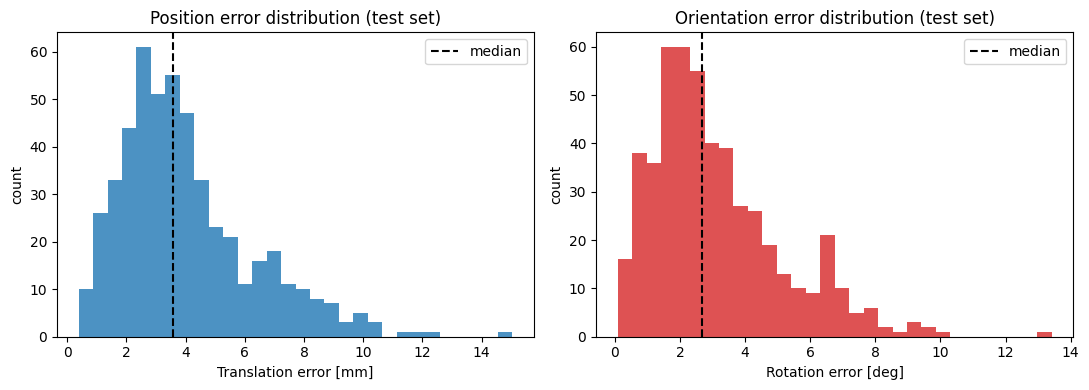

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pos_error, bins=30, color="#1f77b4", alpha=0.8)
axes[0].axvline(np.median(pos_error), color="k", ls="--", label="median")
axes[0].set_xlabel("Translation error [mm]"); axes[0].set_ylabel("count"); axes[0].legend()
axes[0].set_title("Position error distribution (test set)")

axes[1].hist(rot_error_deg, bins=30, color="#d62728", alpha=0.8)
axes[1].axvline(np.median(rot_error_deg), color="k", ls="--", label="median")
axes[1].set_xlabel("Rotation error [deg]"); axes[1].set_ylabel("count"); axes[1].legend()
axes[1].set_title("Orientation error distribution (test set)")
plt.tight_layout()
plt.savefig("results/single_test_error_distributions.pdf")
plt.show()


## Comment 25: does accuracy improve with bending? (currently a qualitative claim in Sections 4.1.1/4.1.2)

Uses radial tip displacement `sqrt(x^2+y^2)` from the ground-truth label as a
proxy for bending magnitude (larger radial displacement = more bent), the
same proxy already used elsewhere in the repo's Grad-CAM analysis cell.

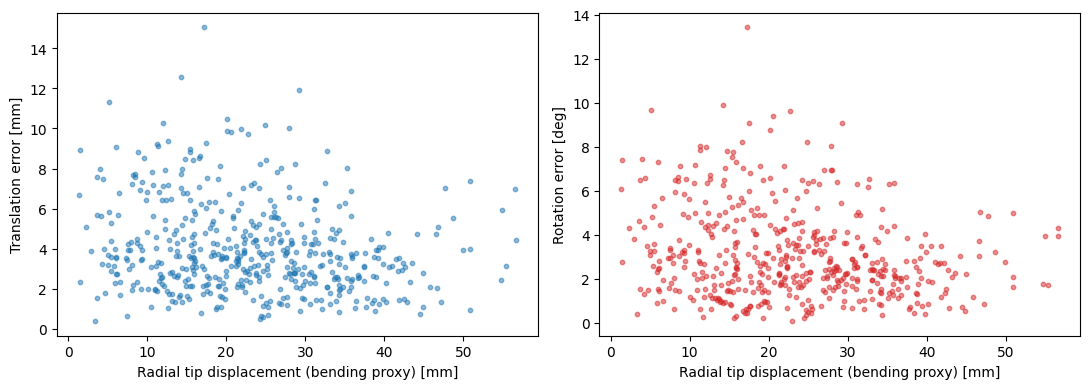

Pearson correlation (bending proxy vs. error): translation r=-0.20, rotation r=-0.20
Negative r supports 'bent configurations improve accuracy'; near-zero or positive would contradict it.


In [7]:

bend_proxy = np.linalg.norm(pos_true[:, :2], axis=1)  # sqrt(x^2+y^2), mm

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(bend_proxy, pos_error, s=10, alpha=0.5, color="#1f77b4")
axes[0].set_xlabel("Radial tip displacement (bending proxy) [mm]")
axes[0].set_ylabel("Translation error [mm]")

axes[1].scatter(bend_proxy, rot_error_deg, s=10, alpha=0.5, color="#d62728")
axes[1].set_xlabel("Radial tip displacement (bending proxy) [mm]")
axes[1].set_ylabel("Rotation error [deg]")
plt.tight_layout()
plt.savefig("results/single_error_vs_bending.pdf")
plt.show()

corr_pos = np.corrcoef(bend_proxy, pos_error)[0, 1]
corr_rot = np.corrcoef(bend_proxy, rot_error_deg)[0, 1]
print(f"Pearson correlation (bending proxy vs. error): translation r={corr_pos:.2f}, rotation r={corr_rot:.2f}")
print("Negative r supports 'bent configurations improve accuracy'; near-zero or positive would contradict it.")


In [8]:

np.savez_compressed("results/SINGLE_test_reconstruction_errors.npz",
                     test_idx=test_idx, pos_error=pos_error, rot_error_deg=rot_error_deg,
                     preds=preds, labels=test_labels, bend_proxy=bend_proxy, seed=SEED)
print("Saved results/SINGLE_test_reconstruction_errors.npz")


Saved results/SINGLE_test_reconstruction_errors.npz
